# In this notebook we explore the respone terms of the single link

In [89]:
import h5py
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("data/")
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = ['Computer Modern']
plt.rcParams['text.usetex'] = True

from lisaconstants import c
from lisaconstants.indexing import LINKS, SPACECRAFT
from pytdi.michelson import X2_ETA, Y2_ETA, Z2_ETA

from segwo.response import compute_strain2link
from segwo_utils import _link_response_boosted

from segwo_utils import InterpolatedOrbits, compute_covariance, compute_strain2x

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

import matplotlib.colors as mcolors


def symmetrical_colormap(cmap_settings, new_name = None ):
    ''' This function take a colormap and create a new one, as the concatenation of itself by a symmetrical fold.
    '''
    # get the colormap
    cmap = plt.cm.get_cmap(*cmap_settings)
    if not new_name:
        new_name = "sym_"+cmap_settings[0]  # ex: 'sym_Blues'
    
    # this defined the roughness of the colormap, 128 fine
    n= 128 
    
    # get the list of color from colormap
    colors_r = cmap(np.linspace(0, 1, n))    # take the standard colormap # 'right-part'
    colors_l = colors_r[::-1]                # take the first list of color and flip the order # "left-part"

    # combine them and build a new colormap
    colors = np.vstack((colors_l, colors_r))
    mymap = mcolors.LinearSegmentedColormap.from_list(new_name, colors)

    return mymap

cmap_settings = ('Blues', None)  # provide int instead of None to "discretize/bin" the colormap
mymap = symmetrical_colormap(cmap_settings= cmap_settings, new_name =None )



In [90]:
with h5py.File("data/processed_trajectories.h5", "r") as ds:
        t_orb_dataset   = ds["t_interp"][()]
        x_orb_dataset   = ds["spacecraft_positions"][()]
        v_orb_dataset   = ds["spacecraft_velocities"][()]
        ltts_dataset    = ds['owlt_12_23_31_13_32_21'][()]

t_orb        = t_orb_dataset
x_orb        = np.median(x_orb_dataset, axis=0)
v_orb        = np.median(v_orb_dataset, axis=0)
ltts_median  = np.median(ltts_dataset,  axis=0)

In [91]:
orbits = InterpolatedOrbits(t_orb, x_orb,
                                spacecraft_velocities=v_orb,
                                ltts=ltts_median,
                                interp_order=3)

perturbed = InterpolatedOrbits(t_orb, x_orb_dataset[0],  # Perturbation of 1 mm in position
                                spacecraft_velocities=v_orb_dataset[0],
                                ltts=ltts_dataset[0],
                                interp_order=3)

In [92]:
array_ltts = np.arange(0,30,1) * 86400.0
print("Number of points in LISA", int(array_ltts[-1]*0.25))

Number of points in LISA 626400


# Inputs to Response

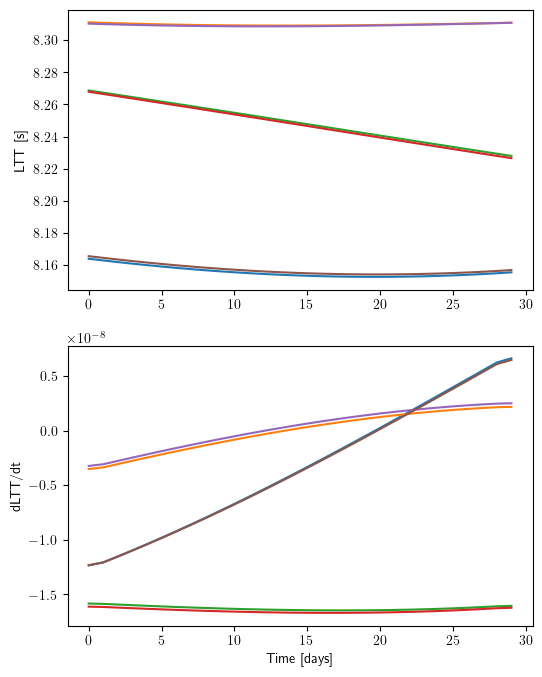

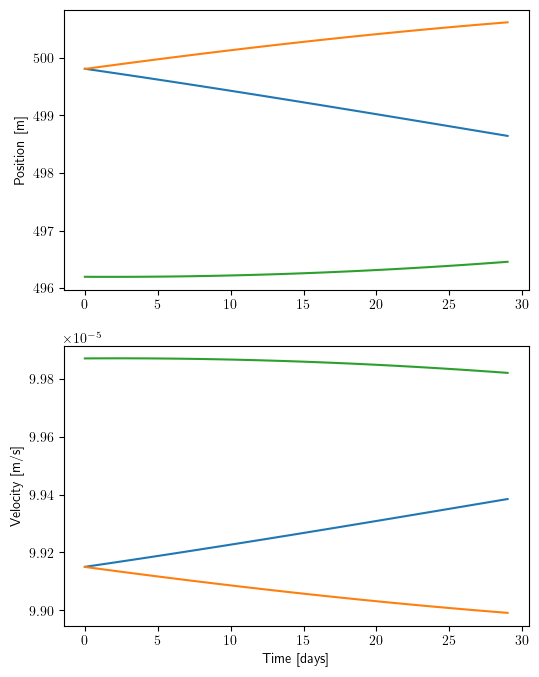

In [93]:
ltts      = orbits.compute_ltt(t=array_ltts)
positions = orbits.compute_position(t=array_ltts)
velocities = orbits.compute_velocity(t=array_ltts)


ltts_perturbed      = perturbed.compute_ltt(t=array_ltts)
positions_perturbed = perturbed.compute_position(t=array_ltts)
velocities_perturbed = perturbed.compute_velocity(t=array_ltts)

_, axes = plt.subplots(2, 1,figsize=(6,8))
for index, link in enumerate(LINKS):
    axes[0].plot(array_ltts/86400, ltts[:, index], label=link)
    axes[1].plot(array_ltts/86400, np.gradient(ltts[:, index], array_ltts), label=link)

plt.xlabel('Time [days]')
axes[0].set_ylabel('LTT [s]')
axes[1].set_ylabel(' dLTT/dt')
plt.show()

_, axes = plt.subplots(2, 1,figsize=(6,8))
for index, link in enumerate(SPACECRAFT):
    axes[0].plot(array_ltts/86400, np.linalg.norm(positions[:, index]/c, axis=1), label=link)
    axes[1].plot(array_ltts/86400, np.linalg.norm(velocities[:, index]/c, axis=1), label=link)

plt.xlabel('Time [days]')
axes[0].set_ylabel('Position [m]')
axes[1].set_ylabel('Velocity [m/s]')
plt.show()

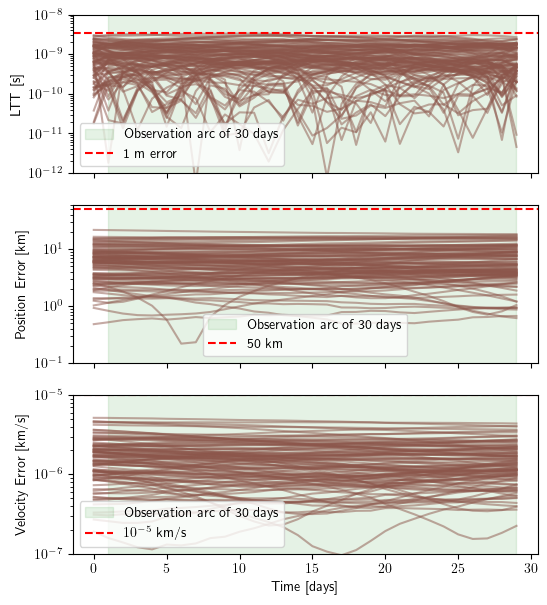

In [94]:
def get_perturbed_ltts_positions_velocities(index=0):
    perturbed_ = InterpolatedOrbits(t_orb, x_orb_dataset[index],  # Perturbation of 1 mm in position
                                spacecraft_velocities=v_orb_dataset[index],
                                ltts=ltts_dataset[index],
                                interp_order=3)
    ltts_perturbed      = perturbed_.compute_ltt(t=array_ltts)
    positions_perturbed = perturbed_.compute_position(t=array_ltts)
    velocities_perturbed = perturbed_.compute_velocity(t=array_ltts)
    return ltts_perturbed, positions_perturbed, velocities_perturbed

_, axes = plt.subplots(3, 1,figsize=(6,7), sharex=True)
for ind in range(100):
    ltts_perturbed_, positions_perturbed_, velocities_perturbed_ = get_perturbed_ltts_positions_velocities(index=ind)
    axes[0].semilogy(array_ltts/86400, np.abs(ltts_perturbed_[:, 0]-ltts[:, 0]), color='C5', alpha=0.5)

    axes[1].semilogy(array_ltts/86400, np.linalg.norm(positions_perturbed_[:, 0]-positions[:, 0], axis=1)/1e3, color='C5', alpha=0.5)
    axes[2].semilogy(array_ltts/86400, np.linalg.norm(velocities_perturbed_[:, 0]-velocities[:, 0], axis=1)/1e3, color='C5', alpha=0.5)


# axes[0].set_ylim(1e-12, 0.5e-3)
axes[0].set_ylim(1e-12, 1e-8)
# axes[1].set_ylim(0.1, 500)
axes[1].set_ylim(0.1, 60)
# axes[2].set_ylim(1e-7, 1e-4)
axes[2].set_ylim(1e-7, 1e-5)

axes[0].set_ylabel('LTT [s]')
axes[1].set_ylabel('Position Error [km]')
axes[2].set_ylabel('Velocity Error [km/s]')
axes[2].set_xlabel('Time [days]')

for ii in range(3):
    axes[ii].fill_between(array_ltts/86400, 0, 1e4, where=(array_ltts/86400<30)&(array_ltts/86400>0),color='green', alpha=0.1, label='Observation arc of 30 days')
axes[0].axhline(1.0/c, color='red', linestyle='--', label='1 m error')
axes[1].axhline(50, color='red', linestyle='--', label='50 km')
axes[2].axhline(1e-5, color='red', linestyle='--', label='$10^{-5}$ km/s')
axes[0].legend()
axes[1].legend()
axes[2].legend()
plt.savefig("paper_plots/perturbation_analysis_evolution.png", dpi=300)
plt.show()
# axes[2].set_xlim(0, 30)

# Response

In [95]:
nside = 2
npix  = hp.nside2npix(nside)
thetas, phis = hp.pix2ang(nside, np.arange(npix))
# betas, lambs = np.pi / 2 - thetas, phis
betas, lambs = np.pi / 2 - np.array([np.pi/3]), np.array([np.pi/3])
f = np.logspace(-4, 0., 500)

strain2link = compute_strain2link(f, betas, lambs, ltts, positions, method="baghi+23")
strain2link_boosted = _link_response_boosted(f, betas, lambs, ltts, positions, velocities=velocities)
strain2link_boosted_perturbed = _link_response_boosted(f, betas, lambs, ltts_perturbed, positions_perturbed, velocities=velocities_perturbed)
strain2link_boosted.shape

(30, 500, 1, 6, 2)

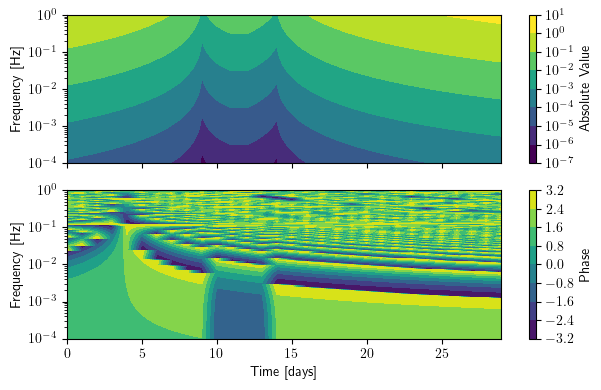

In [96]:
link = 0  # Choose A, E, or T
pol = 0  # Choose polarization
sky_index = 0  # Choose a specific sky location (pixel index)
time_index = 0  # Choose a specific time index

response = strain2link[:, :, sky_index, link, pol]# / f
amp_map = (np.abs(response).T)
phase_map = (np.angle(response).T)

fig, axes = plt.subplots(2, 1, figsize=(3.15*2, 4), sharex=True)

positive_vals = amp_map[amp_map > 0]
vmin = positive_vals.min()

cf1 = axes[0].contourf(
    array_ltts / 86400,
    f,
    amp_map,
    levels=5,
    norm=mcolors.LogNorm(vmin=vmin, vmax=amp_map.max())
)
fig.colorbar(cf1, ax=axes[0], label='Absolute Value')
# axes[0].axhline(1 / (np.pi * 8.2), color='r')
# axes[0].set_ylim(1e-2, 1)
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_yscale('log')

cf2 = axes[1].contourf(array_ltts / 86400, f, phase_map)#, cmap=mymap)
fig.colorbar(cf2, ax=axes[1], label='Phase')
# axes[1].axhline(1 / (np.pi * 8.2), color='r')
axes[1].set_xlabel('Time [days]')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig("response_evolution.png", dpi=300)

with h5py.File("data/link_response_maps.h5", "w") as ds:
    ds.create_dataset("array_ltts", data=array_ltts)
    ds.create_dataset("frequencies", data=f)
    ds.create_dataset("amp_map", data=amp_map)
    ds.create_dataset("phase_map", data=phase_map)


Text(0, 0.5, 'Real part of strain2link')

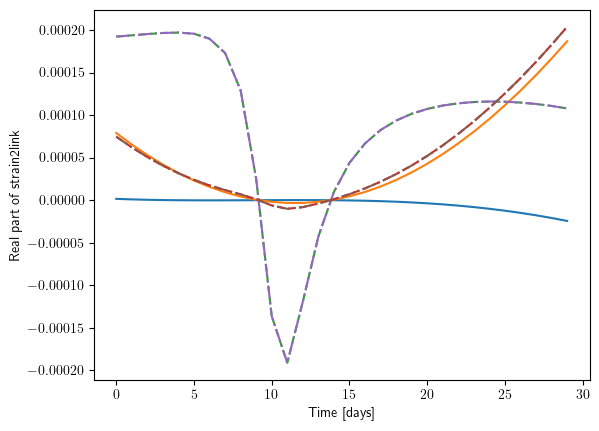

In [97]:
link = 0  # Choose A, E, or T
pol = 0  # Choose polarization
sky_index = 0  # Choose a specific sky location (pixel index)
time_index = 0  # Choose a specific time index

plt.figure()
plt.plot(array_ltts / 86400, strain2link[:, 0, sky_index, link, pol].real)
plt.plot(array_ltts / 86400, strain2link[:, 0, sky_index, link, pol].imag)
plt.plot(array_ltts / 86400, strain2link_boosted[:, 0, sky_index, link, pol].real, '--')
plt.plot(array_ltts / 86400, strain2link_boosted[:, 0, sky_index, link, pol].imag, '--')
plt.plot(array_ltts / 86400, strain2link_boosted_perturbed[:, 0, sky_index, link, pol].real, '-.')
plt.plot(array_ltts / 86400, strain2link_boosted_perturbed[:, 0, sky_index, link, pol].imag, '-.')
plt.xlabel('Time [days]')
plt.ylabel('Real part of strain2link')


(30, 500, 1, 6, 2)


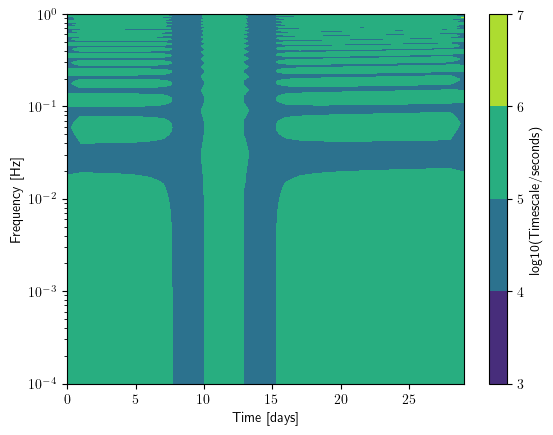

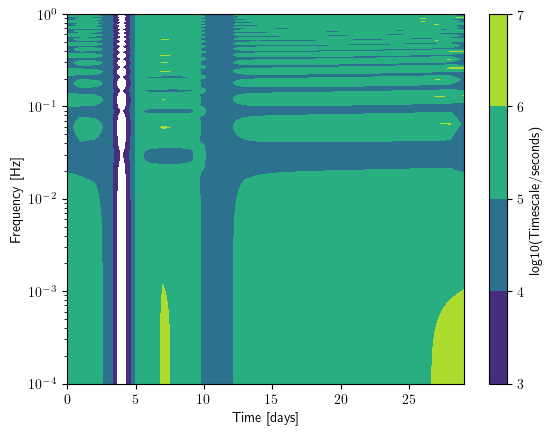

In [98]:
link = 0

Timescale_response = np.abs(strain2link / np.gradient(strain2link, array_ltts, axis=0))
print(Timescale_response.shape)

plt.figure()
plt.contourf(array_ltts / 86400, f, np.log10(Timescale_response[:, :, sky_index, link, 0].T), levels=[3, 4, 5, 6, 7])
plt.yscale('log')
plt.colorbar(label='log10(Timescale/seconds)')
plt.xlabel('Time [days]')
plt.ylabel('Frequency [Hz]')
plt.show()

plt.figure()
plt.contourf(array_ltts / 86400, f, np.log10(Timescale_response[:, :, sky_index, link, 1].T), levels=[3, 4, 5, 6, 7])
plt.yscale('log')
plt.colorbar(label='log10(Timescale/seconds)')
plt.xlabel('Time [days]')
plt.ylabel('Frequency [Hz]')
plt.show()


(30, 500, 1, 6, 2)


Text(0, 0.5, 'Frequency [Hz]')

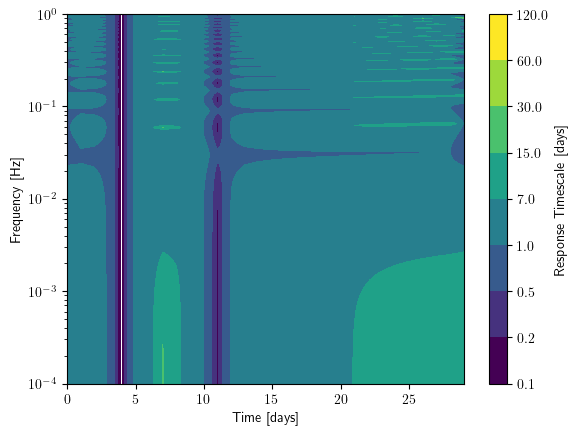

In [99]:
import matplotlib.colors as colors
# sum across polarization
Timescale_response = np.abs(strain2link / np.gradient(strain2link, array_ltts, axis=0))
# fix plus polarization
# Timescale_response = (np.abs(strain2AET_boosted / np.gradient(strain2AET_boosted, array_ltts, axis=0))[...,0])
print(Timescale_response.shape)
levels = [1/12, 0.25, 0.5, 1, 7, 15, 30, 60, 120]

norm = colors.BoundaryNorm(levels, ncolors=plt.get_cmap('viridis').N, clip=True)

plt.figure()
cf = plt.contourf(
    array_ltts / 86400,
    f,
    Timescale_response[:, :, 0, 0, 1].T / 86400,
    levels=levels,
    cmap='viridis',
    norm=norm
)

plt.yscale('log')
plt.colorbar(cf, label='Response Timescale [days]')
plt.xlabel('Time [days]')
plt.ylabel('Frequency [Hz]')

# Study relativistic impact

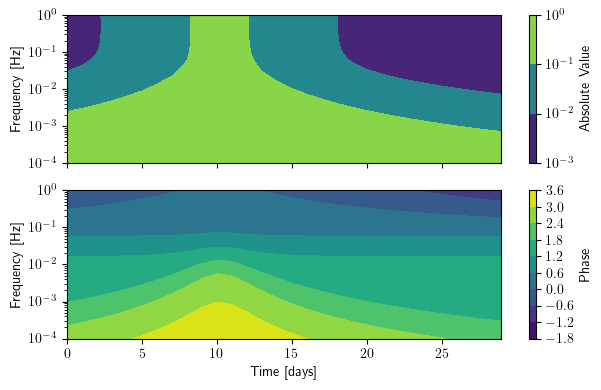

In [100]:
response_rel = (strain2link[:, :, sky_index, link, pol] - strain2link_boosted[:, :, sky_index, link, pol]) / strain2link_boosted[:, :, sky_index, link, pol]

amp_map = (np.abs(response_rel).T)
phase_map = (np.angle(response_rel).T)

fig, axes = plt.subplots(2, 1, figsize=(3.15*2, 4), sharex=True)

positive_vals = amp_map[amp_map > 0]
vmin = positive_vals.min()

cf1 = axes[0].contourf(
    array_ltts / 86400,
    f,
    amp_map,
    levels=5,
    norm=mcolors.LogNorm(vmin=vmin, vmax=amp_map.max())
)
fig.colorbar(cf1, ax=axes[0], label='Absolute Value')
# axes[0].axhline(1 / (np.pi * 8.2), color='r')
# axes[0].set_ylim(1e-2, 1)
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_yscale('log')

cf2 = axes[1].contourf(array_ltts / 86400, f, phase_map)#, cmap=mymap)
fig.colorbar(cf2, ax=axes[1], label='Phase')
# axes[1].axhline(1 / (np.pi * 8.2), color='r')
axes[1].set_xlabel('Time [days]')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig("response_evolution.png", dpi=300)

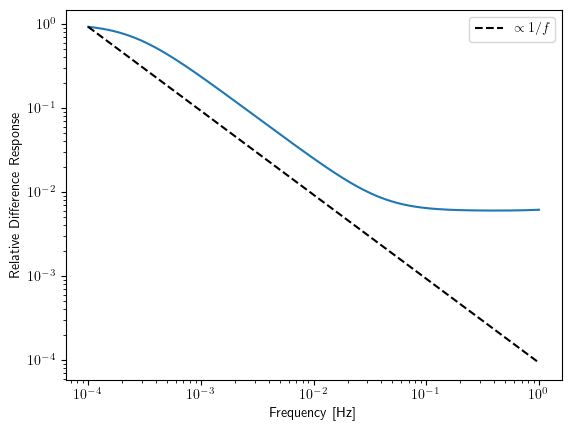

In [101]:

plt.figure()
plt.loglog(f,  amp_map[:,0], label='')
plt.loglog(f,  amp_map[0,0]*(f[0]/f), 'k--', label=r"$\propto 1/f$")
plt.xlabel('Frequency [Hz]')
plt.ylabel('Relative Difference Response')
plt.legend()
plt.show()

# Study orbits impact

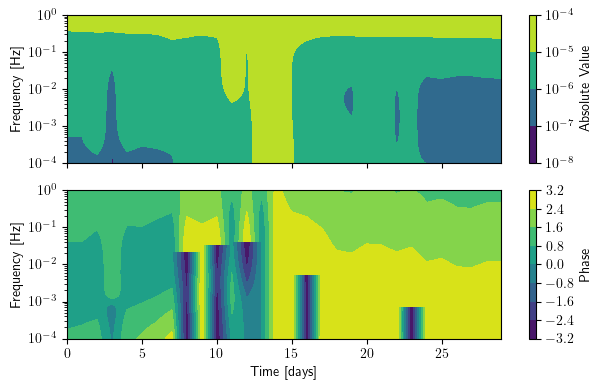

In [102]:
response_orb = (strain2link_boosted_perturbed[:, :, sky_index, link, pol] - strain2link_boosted[:, :, sky_index, link, pol]) / strain2link_boosted[:, :, sky_index, link, pol]

amp_map = (np.abs(response_orb).T)
phase_map = (np.angle(response_orb).T)

fig, axes = plt.subplots(2, 1, figsize=(3.15*2, 4), sharex=True)

positive_vals = amp_map[amp_map > 0]
vmin = positive_vals.min()

cf1 = axes[0].contourf(
    array_ltts / 86400,
    f,
    amp_map,
    levels=5,
    norm=mcolors.LogNorm(vmin=vmin, vmax=amp_map.max())
)
fig.colorbar(cf1, ax=axes[0], label='Absolute Value')
# axes[0].axhline(1 / (np.pi * 8.2), color='r')
# axes[0].set_ylim(1e-2, 1)
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_yscale('log')

cf2 = axes[1].contourf(array_ltts / 86400, f, phase_map)#, cmap=mymap)
fig.colorbar(cf2, ax=axes[1], label='Phase')
# axes[1].axhline(1 / (np.pi * 8.2), color='r')
axes[1].set_xlabel('Time [days]')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig("response_evolution.png", dpi=300)

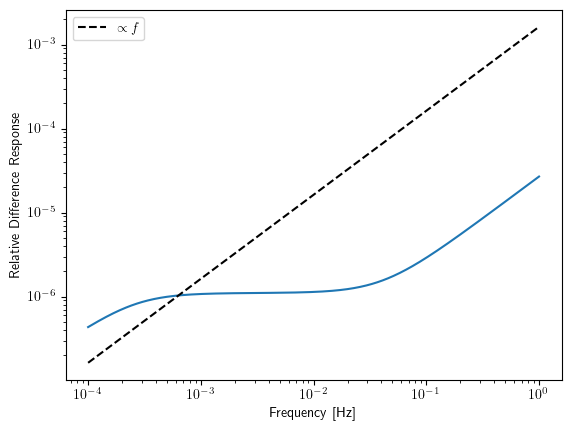

In [103]:
plt.figure()
plt.loglog(f,  amp_map[:,0], label='')
plt.loglog(f,  amp_map[100,0]*(f/f[100]), 'k--', label=r"$\propto f$")
plt.xlabel('Frequency [Hz]')
plt.ylabel('Relative Difference Response')
plt.legend()
plt.show()

# Comparison of the effects

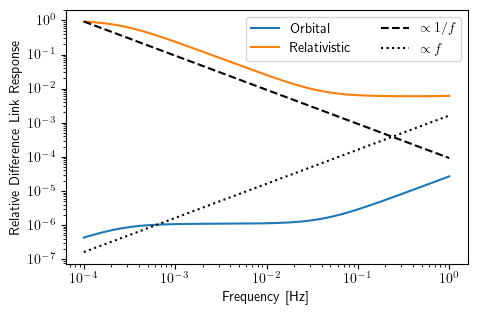

In [104]:
amp_orb = (np.abs(response_orb).T)
amp_rel = (np.abs(response_rel).T)
plt.figure(figsize=(3.25*1.5,3.25))
plt.loglog(f,  amp_orb[:,0], label='Orbital')
# plt.loglog(f,  np.mean(amp_orb,axis=1), label='Orbital')
plt.loglog(f,  amp_rel[:,0], label='Relativistic')
# plt.loglog(f,  np.mean(amp_rel,axis=1), label='Relativistic')
plt.loglog(f,  amp_rel[0,0]*(f[0]/f), 'k--', label=r"$\propto 1/f$")
plt.loglog(f,  amp_orb[100,0]*(f/f[100]), 'k:', label=r"$\propto f$")
plt.xlabel('Frequency [Hz]')
plt.ylabel('Relative Difference Link Response')
plt.legend(ncols=2)
plt.tight_layout()
plt.savefig("paper_plots/response_comparison.png", dpi=300)

<Figure size 640x480 with 0 Axes>

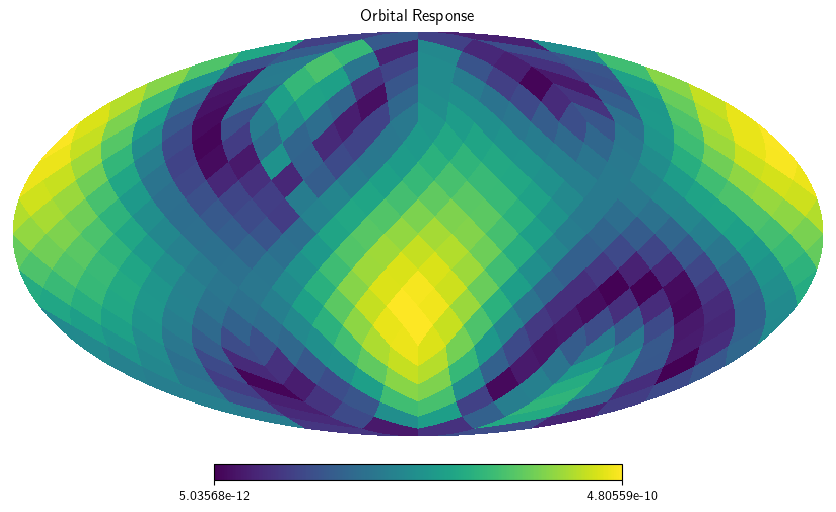

<Figure size 640x480 with 0 Axes>

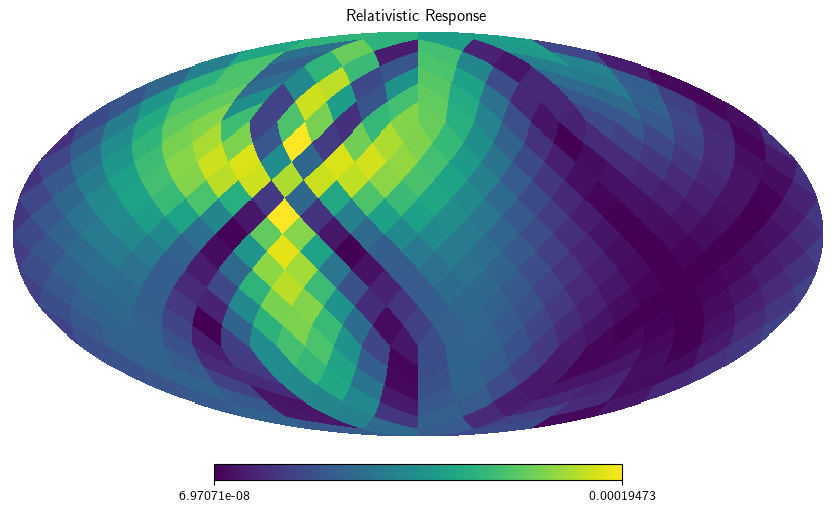

In [105]:
nside = 6
npix  = hp.nside2npix(nside)
thetas, phis = hp.pix2ang(nside, np.arange(npix))
betas, lambs = np.pi / 2 - thetas, phis
f = np.logspace(-4, 0., 10)

strain2link = compute_strain2link(f, betas, lambs, ltts, positions, method="baghi+23")
strain2link_boosted = _link_response_boosted(f, betas, lambs, ltts, positions, velocities=velocities)
strain2link_boosted_perturbed = _link_response_boosted(f, betas, lambs, ltts_perturbed, positions_perturbed, velocities=velocities_perturbed)


freq_index = 0
response_orb = (strain2link_boosted_perturbed[:, freq_index, :, link, pol] - strain2link_boosted[:, freq_index, :, link, pol])# / strain2link_boosted[:, freq_index, :, link, pol]
response_rel = (strain2link[:, freq_index, :, link, pol] - strain2link_boosted[:, freq_index, :, link, pol])# / strain2link_boosted[:, freq_index, :, link, pol]
strain2link_boosted_perturbed.shape
plt.figure()
hp.mollview(np.abs(response_orb[2]), title="Orbital Response")
plt.show()
plt.figure()
hp.mollview(np.abs(response_rel[2]), title="Relativistic Response")
plt.show()


# Time evolving inner product

In [106]:
nside = 6
npix  = hp.nside2npix(nside)
thetas, phis = hp.pix2ang(nside, np.arange(npix))
betas, lambs = np.pi / 2 - thetas, phis
betas, lambs = np.pi / 2 - np.array([np.pi/3]), np.array([np.pi/3])
f = np.logspace(-4, -2., 100)
f = np.append(f, np.logspace(-2., 0., 200))
f = np.unique(np.sort(f))


cov_AET = compute_covariance(f, ltts_median)[:,:,np.newaxis,:,:] # added an axis for sky pixels
cov_AET = cov_AET.mean(axis=0)[None,...]
inv_cov_AET = np.linalg.inv(cov_AET)

array_ltts = np.linspace(0, 30, num=240) * 86400.0

ltts      = orbits.compute_ltt(t=array_ltts)
positions = orbits.compute_position(t=array_ltts)
velocities = orbits.compute_velocity(t=array_ltts)

ltts_perturbed      = perturbed.compute_ltt(t=array_ltts)
positions_perturbed = perturbed.compute_position(t=array_ltts)
velocities_perturbed = perturbed.compute_velocity(t=array_ltts)

strain2AET_boosted = compute_strain2x(f, betas, lambs, ltts, positions, velocities=velocities)
strain2AET_boosted_perturbed = compute_strain2x(f, betas, lambs, ltts_perturbed, positions_perturbed, velocities=velocities_perturbed)

In [120]:
strain2AET_boosted.shape

(240, 299, 1, 3, 2)

(240, 299, 1, 3, 2)


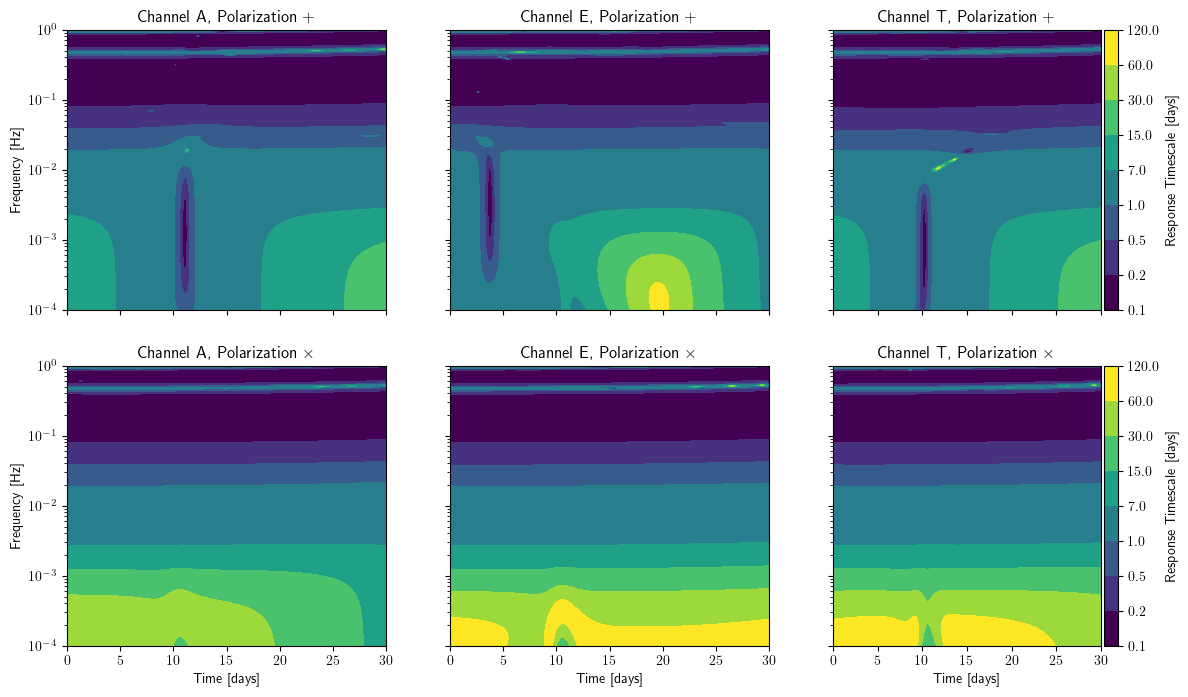

In [153]:
import matplotlib.colors as colors
# sum across polarization
Timescale_response = np.abs(
    strain2AET_boosted
                            /np.gradient(strain2AET_boosted, array_ltts, axis=0)
                            )
# fix plus polarization
# Timescale_response = (np.abs(strain2AET_boosted / np.gradient(strain2AET_boosted, array_ltts, axis=0))[...,0])
print(Timescale_response.shape)
levels = [1/12, 0.25, 0.5, 1, 7, 15, 30, 60, 120]

norm = colors.BoundaryNorm(levels, ncolors=plt.get_cmap('viridis').N, clip=True)

# plt.figure()


fig, axs = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)

for ch in range(3):
    for pol in range(2):
        cf = axs[pol, ch].contourf(
            array_ltts / 86400,
            f,
            Timescale_response[:, :, 0, ch, pol].T / 86400,
            levels=levels,
            cmap='viridis',
            norm=norm
        )
        axs[pol, ch].set_title(f"Channel {["A", "E", "T"][ch]}, Polarization {['$+$', r'$\times$'][pol]}")
        axs[pol, ch].set_yscale('log')
        if pol == 1:
            axs[pol, ch].set_xlabel('Time [days]')
        if ch == 0:
            axs[pol, ch].set_ylabel('Frequency [Hz]')
            
        if ch == 2:
            fig.colorbar(cf, ax=axs[pol, ch], label='Response Timescale [days]', pad=0.01)

# cf = plt.contourf(
#     array_ltts / 86400,
#     f,
#     Timescale_response[:, :].T / 86400,
#     levels=levels,
#     cmap='viridis',
#     norm=norm
# )

plt.yscale('log')
plt.savefig("paper_plots/response_timescale.png", dpi=300)

with h5py.File("data/response_timescale_map.h5", "w") as ds:
    ds.create_dataset("array_ltts", data=array_ltts)
    ds.create_dataset("frequencies", data=f)
    ds.create_dataset("timescale_response", data=Timescale_response)
    

Amp map shape (299, 240)
f shape (299,)
array_ltts shape (240,)


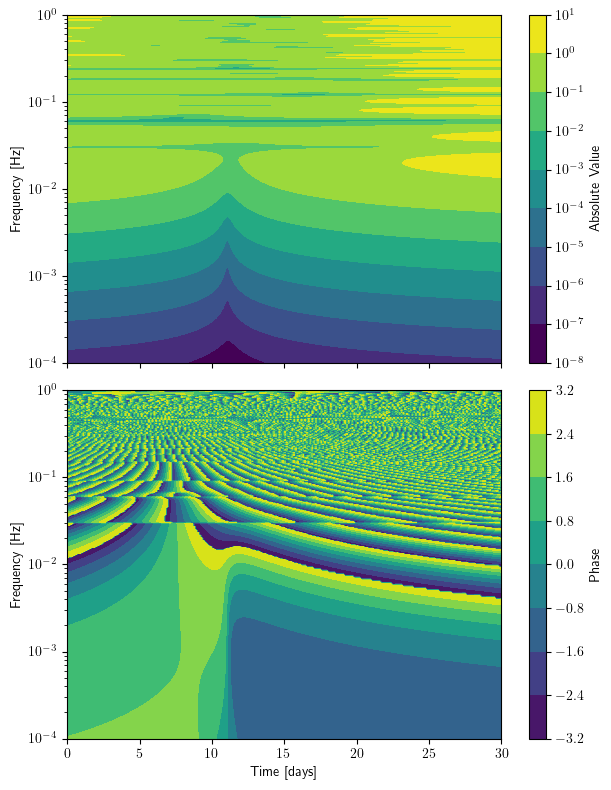

In [108]:
link = 0  # Choose A, E, or T
pol = 0  # Choose polarization
sky_index = 0  # Choose a specific sky location (pixel index)
time_index = 0  # Choose a specific time index

response = strain2AET_boosted[:, :, sky_index, link, pol]# / f
amp_map = (np.abs(response).T)
phase_map = (np.angle(response).T)

response_pert = strain2AET_boosted_perturbed[:, :, sky_index, link, pol]# / f
amp_map_pert = (np.abs(response_pert).T)
phase_map_pert = (np.angle(response_pert).T)

fig, axes = plt.subplots(2, 1, figsize=(3.15*2, 8), sharex=True)

positive_vals = amp_map[amp_map > 0]
vmin = positive_vals.min()

print("Amp map shape", amp_map.shape)
print("f shape", f.shape)
print("array_ltts shape", array_ltts.shape)
cf1 = axes[0].contourf(
    array_ltts / 86400,
    f,
    amp_map,
    levels=5,
    norm=mcolors.LogNorm(vmin=vmin, vmax=amp_map.max())
)
fig.colorbar(cf1, ax=axes[0], label='Absolute Value')
# axes[0].axhline(1 / (np.pi * 8.2), color='r')
# axes[0].set_ylim(1e-2, 1)
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_yscale('log')

cf2 = axes[1].contourf(array_ltts / 86400, f, phase_map)#, cmap=mymap)
fig.colorbar(cf2, ax=axes[1], label='Phase')
# axes[1].axhline(1 / (np.pi * 8.2), color='r')
axes[1].set_xlabel('Time [days]')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

In [109]:

with h5py.File("data/response_evolution_plot.h5", "w") as ds:
    ds.create_dataset("array_ltts", data=array_ltts)
    ds.create_dataset("frequencies", data=f)
    ds.create_dataset("phase_map", data=phase_map)
    ds.create_dataset("amp_map", data=amp_map)
    ds.create_dataset("phase_map_pert", data=phase_map_pert)
    ds.create_dataset("amp_map_pert", data=amp_map_pert)
    ds.create_dataset("ltts", data=ltts)
print("Saved data for response evolution plot.")

Saved data for response evolution plot.


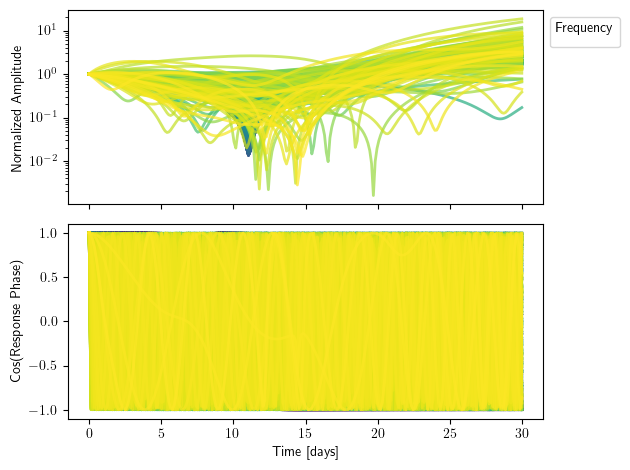

In [110]:

fig, (ax_amp, ax_phase) = plt.subplots(2, 1, sharex=True)

t_days = array_ltts / 86400.0
freq_vals = np.asarray(f)

if np.all(freq_vals > 0):
    norm = mcolors.LogNorm(vmin=freq_vals.min(), vmax=freq_vals.max())
    cbar_label = "Frequency [Hz]"
else:
    norm = mcolors.Normalize(vmin=freq_vals.min(), vmax=freq_vals.max())
    cbar_label = "Frequency"

cmap = plt.cm.viridis
colors = [cmap(norm(fi)) for fi in freq_vals]
# colors = WONG_COLORS[:len(freq_vals)]  # Override with Wong palette for better visibility

for i, (fi, color) in enumerate(zip(freq_vals[:-1], colors[:-1])):
    ax_amp.semilogy(t_days, amp_map[i]/amp_map[i][0], color=color, lw=2, alpha=0.7) # , label=f"{fi:.2} Hz"
    ax_phase.plot(t_days, np.cos(phase_map[i]-phase_map[i][0]), color=color, lw=2, alpha=0.7)

ax_amp.set_ylabel("Normalized Amplitude")
# ax_amp.set_title("Response amplitude evolution")
ax_amp.legend(title="Frequency", bbox_to_anchor=(1.00, 1), loc='upper left', title_fontsize=10)

ax_phase.set_ylabel(r"Cos(Response Phase)")
ax_phase.set_xlabel("Time [days]")
# ax_phase.set_title("Response phase evolution")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

plt.tight_layout()
plt.show()

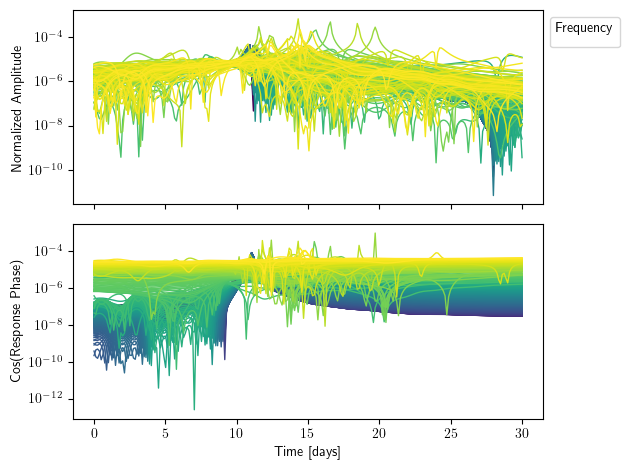

In [111]:


fig, (ax_amp, ax_phase) = plt.subplots(
    2, 1, sharex=True
)

t_days = array_ltts / 86400.0
freq_vals = np.asarray(f)

if np.all(freq_vals > 0):
    norm = mcolors.LogNorm(vmin=freq_vals.min(), vmax=freq_vals.max())
    cbar_label = "Frequency [Hz]"
else:
    norm = mcolors.Normalize(vmin=freq_vals.min(), vmax=freq_vals.max())
    cbar_label = "Frequency"

cmap = plt.cm.viridis

for i, fi in enumerate(freq_vals):
    color = cmap(norm(fi))
    ax_amp.semilogy(t_days, np.abs(1-amp_map[i]/amp_map_pert[i]), color=color, lw=1)#, label=f"{fi:.2} Hz")
    ax_phase.semilogy(t_days, np.abs(phase_map[i] - phase_map_pert[i]), color=color, lw=1)

ax_amp.set_ylabel("Normalized Amplitude")
# ax_amp.set_title("Response amplitude evolution")
ax_amp.legend(title="Frequency", bbox_to_anchor=(1.00, 1), loc='upper left', title_fontsize=10)

ax_phase.set_ylabel(r"Cos(Response Phase)")
ax_phase.set_xlabel("Time [days]")
# ax_phase.set_title("Response phase evolution")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

plt.tight_layout()

In [112]:
A_A = 4 * np.einsum("ijklm,ijklr,ijkrm->ijk",np.conj(strain2AET_boosted), inv_cov_AET, strain2AET_boosted).real
A_B = 4 * np.einsum("ijklm,ijklr,ijkrm->ijk",np.conj(strain2AET_boosted), inv_cov_AET, strain2AET_boosted_perturbed).real
B_B = 4 * np.einsum("ijklm,ijklr,ijkrm->ijk",np.conj(strain2AET_boosted_perturbed), inv_cov_AET, strain2AET_boosted_perturbed).real
mismatch_boost = np.abs(1 - A_B / (B_B * A_A)**0.5)
mismatch_boost.shape

(240, 299, 1)

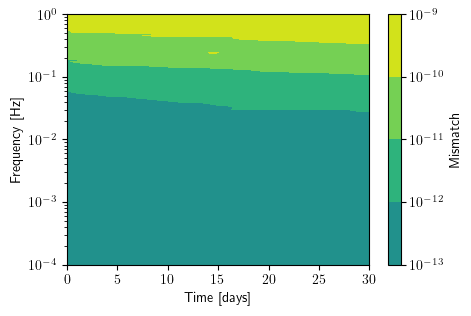

In [113]:
sky_index = 0  # Choose a specific sky location (pixel index)
plt.figure(figsize=(3.25*1.5,3.25))
plt.contourf(array_ltts / 86400, f, mismatch_boost[:,:,sky_index].T, levels=5, norm=mcolors.LogNorm(vmin=1e-16, vmax=mismatch_boost.max()))
plt.colorbar(label='Mismatch')
plt.xlabel('Time [days]')
plt.ylabel('Frequency [Hz]')
plt.yscale('log')
plt.show()

In [114]:
# hp.mollview(mismatch_boost[0,0], title='Mismatch Map', cmap='viridis')

(240, 299, 1)

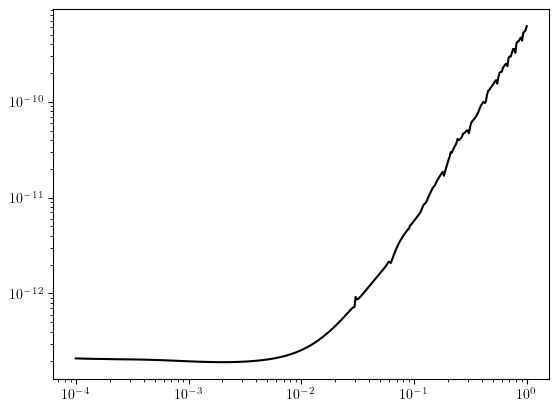

In [115]:
# [:array_ltts<15*86400]
mask_time = array_ltts<365*86400
plt.figure()
plt.loglog(f, np.mean(mismatch_boost[mask_time], axis=(0,2)), color='k', label='Response Only Mismatch')
mismatch_boost.shape